# Enhancing AI Agent Tool-Calling Accuracy Through Fine-Tuning


## Agenda
![Title Diagram](./img/agenda.png)

## Demo Goal: Improving the Zava Retail Agent

**Zava** is a fictional retail brand with an AI agent powered by Microsoft Foundry and a Retail MCP Server.

**What works:** Base models handle simple single-tool calls (e.g., "show me products") ✅  
**What fails:** Complex multi-turn scenarios requiring tool chaining and parameter propagation ❌

**This notebook demonstrates:**
1. Synthetic data generation using Microsoft Foundry
2. Supervised fine-tuning (SFT) for tool-calling accuracy
3. Python-based evaluation with custom graders
4. Measuring improvements across model sizes

## 1. Architecture Overview

### The Zava Agent System

**Microsoft Foundry Agent Service** (orchestrator)
- Interprets customer intent
- Selects appropriate tools
- Constructs structured tool-call arguments
- Produces customer-friendly responses

**Retail MCP Server** (tool provider)  
Exposes 9 tools across 4 categories:

```
User Lookup
 ├─ find_user_id_by_email
 ├─ find_user_id_by_name_zip
 └─ get_user_details

Orders
 ├─ get_order_details
 ├─ cancel_pending_order
 └─ exchange_delivered_order_items

Products
 ├─ list_products
 └─ get_product_details

Customer Profile
 └─ update_address
```

### Request Flow

```
Customer Message
       ↓
Agent (LLM + Policies + Tool Schemas)
       ↓
MCP Server (executes tool)
       ↓
Tool Output (JSON) → Agent Reasoning
       ↓
Final Response
```

### Architecture Diagram

<img src="img/architecture.png" alt="Zava Architecture" width="600">

### What Fine-Tuning Improves

- **Tool chaining** - Correct sequence of tool calls
- **Parameter propagation** - Carrying IDs and data across turns
- **Policy alignment** - Enforcing business rules
- **Multi-turn consistency** - Maintaining state over long interactions

## 2. Prerequisites & Environment Setup

### Azure Resources Required

✅ Microsoft Foundry Hub & Project  
✅ Azure OpenAI deployments: `gpt-4.1`, `gpt-4.1-mini` 
✅ Azure AI Search with vector index populated with product embeddings  
✅ Retail MCP Server running and accessible  


See [infra/README.md](../src/00-setup.md) for detailed setup instructions.


### Test MCP Server Connectivity

Verify that your MCP server is reachable and the agent can access it.

In [5]:
# Quick connectivity test using the MCP test utility
import sys
sys.path.append('tools')

from test_mcp_connectivity import MCPConnectivityTester, quick_test
from dotenv import load_dotenv
import os

load_dotenv()

# Get MCP server URL from environment or use default
mcp_url = os.getenv("MCP_SERVER_URL")

# Clean up URL - remove trailing /mcp if present and strip port if it's default HTTPS
mcp_url = mcp_url.rstrip('/mcp').rstrip(':443')
print(f"🔍 Testing MCP Server\n")
print(f"🌐 MCP Server URL: {mcp_url}\n")

# Quick test first
if quick_test(mcp_url):
    print("✅ Server is reachable!\n")
    
    # Run full test suite with notebook-friendly formatting
    tester = MCPConnectivityTester(mcp_url)
    tester.run_all_tests(notebook_mode=True)
else:
    print("❌ Server is not reachable. Please check the URL and your network connection.")

🔍 Testing MCP Server

🌐 MCP Server URL: https://retail-mcp-server-sim.braveflower-06b407cc.eastus.azurecontainerapps.io

✅ Server is reachable!

🔌 MCP Server Connectivity Test Suite
Server: https://retail-mcp-server-sim.braveflower-06b407cc.eastus.azurecontainerapps.io

Testing health check endpoint...
✓ Health check passed
  Status: 200
  Response: {'status': 'healthy', 'version': '1.0.0', 'active_sessions': 0}

Testing root endpoint...
✓ Root endpoint accessible
  Status: 200
  Content length: 16336 bytes

Testing /tools endpoint (OpenAI compatible)...
✓ Tools endpoint working
  Status: 200
  Response type: function_call_output
  Call ID: call_test_001
  Output: {'T-Shirt': '9523456873', 'Laptop': '4760268021', 'Running Shoes': '6938111410', 'Smartphone': '1801728040', 'Backpack': '2524789262', 'Coffee Maker': '7996920482', 'Water Bottle': '8310926033', 'Desk Lamp': '6817146515', 'Notebook': '2892623495', 'Sunglasses': '7314138884', 'Wristwatch': '6066914160', 'Electric Toothbrush': 

## Agent in Microsoft Foundry

### Create an Agent in Microsoft Foundry

1. **Open [Microsoft Foundry](https://ai.azure.com)**, select the **Build** tab and in the left navigation select **Agent.**
1. In the Agent tab, select **Create agent** and create a new agent with the name **ZavaRetail**.
1. Under thte new agent create, scroll down to **tools** and select **add a new tool.**
1. In the new tab select **custom** tab and click **Model Context Protocol (MCP)**
1. **Configure the MCP tool as follows:**
   - Name: `zavamcp`
   - Remote MCP Server endpoint: `https://retail-mcp-server-sim.braveflower-06b407cc.eastus.azurecontainerapps.io`
   - Authentication: `Unauthenticated`
1. Once configured, click **connect** to add the tool to your agent
1. Next, add the system instructions to you agent, you can find all instructions at: `./02-system-prompt.md`
1. Interact with the agent asking the following questions. Change between model to check how well the tool calling works.
    - Hi, I am Noah, zip code 80279, what products do you have?
    - "Hi, I am Noah, zip code 80279 and email noah.brown7922@example.com; I want to update my address to 2345 East End."

## 4. Agent Creation with Tools & Policies

### System Instructions & Business Policy

The agent receives:
1. **Identity**: "You are a helpful customer service agent for Zava..."
2. **Capabilities**: Access to user lookup, orders, products, profile updates via MCP
3. **Business Rules**: Encoded in the policy document

**Key Policy Rules:**

```markdown
EXCHANGE_POLICY
- Delivered orders: Exchange ONLY, no cancellations
- Pending orders: Cancel or exchange allowed
- Must use cancel_pending_order() or exchange_delivered_order_items()

USER_IDENTIFICATION_POLICY
- ALWAYS look up user_id FIRST before any order/profile operations
- Use find_user_id_by_email() or find_user_id_by_name_zip()
- Never proceed without valid user_id

INFORMATION_DISCLOSURE_POLICY
- Share order/user info ONLY after successful identification
- No speculation on unavailable data
```

These policies are critical - base models often violate them without fine-tuning.

### OpenAPI Specification with Policy Annotations

The MCP server exposes its tools via an OpenAPI spec enriched with business policies:

**Structure:**
- **paths**: Tool endpoints (e.g., `/find_user_id_by_name_zip`)
- **x-policy**: Policy annotations per tool
- **parameters**: Required/optional fields with validation rules

**Example Tool Definition:**

```json
{
  "paths": {
    "/find_user_id_by_name_zip": {
      "post": {
        "summary": "Find user ID using name and zip code",
        "x-policy": "ALWAYS use this before operations requiring user_id",
        "parameters": {
          "name": {"type": "string", "required": true},
          "zip": {"type": "string", "required": true}
        }
      }
    }
  }
}
```

The `x-policy` fields reinforce behavioral constraints that must be learned through fine-tuning.

### Baseline Agent Behavior (Pre-Fine-Tuning)

**Test Scenario:**  
Customer: *"Hi, I'm Noah, zip code 80279, and I want to update my address."*

**Expected Flow:**
1. ✅ Call `find_user_id_by_name_zip(name="Noah", zip="80279")`
2. ✅ Get `user_id` from response
3. ✅ Call `update_address(user_id=<id>, new_address=<address>)`

**Actual Base Model Behavior:**

❌ **Problem 1: Skips User Lookup**  
Calls `update_address()` immediately without `user_id`

❌ **Problem 2: Hallucinates Parameters**  
Invents fake `user_id` instead of calling lookup tool

❌ **Problem 3: Violates Policy**  
Ignores `USER_IDENTIFICATION_POLICY` requiring lookup first

**Why It Fails:**
- Base models lack training on complex tool chaining patterns
- They don't internalize policy constraints from system prompts alone
- Parameter propagation across tools requires explicit fine-tuning examples

**Solution:** Supervised fine-tuning with tool-calling demonstrations

### Create Microsoft Foundry Agent

Initialize the agent with:
- Model deployment (gpt-4.1)
- System instructions + business policies
- OpenAPI tool schema from MCP server
- Azure AI Search integration

## 5. Generating Synthetic Training Data

### Create Training Data in Microsoft Foundry

1. **Open [Microsoft Foundry](https://ai.azure.com)**, select the **Build** tab and in the left navigation select **Data.**
1. In the Data tab, select **Synthetic data generation,** and click on the **Generate data** button.
1. **Configure create data job:**
   - Task type: `Tool use`
   - Reference file: `/02-openapi_with_policy.json`
   - Maximum number of samples: `500`
   - Generator model: `gpt-4.1`
   - Split data into training and vailidation sets: `turn on`
   - Output file name: leave defaults
1. Once the data file is updated, click **Generate** button to generate the synthetic dataset.
1. Wait ~15-20 minutes for the dataset to be generated. It will be a JSONL with system prompts, user messages, tool calls, and tool responses ready for fine-tuning.

### What Gets Generated

The synthetic dataset contains 500 training and 100 validation conversations generated by `gpt-4.1` (temperature: 0.7, max tokens: 4096) covering user lookups, order operations, product queries, address updates, and multi-step tool chaining workflows across all 9 MCP tools, producing JSONL-formatted conversations ready for supervised fine-tuning in approximately 15-20 minutes.



## 6. Supervised Fine-Tuning (SFT)

### Fine-Tuning Process in Microsoft Foundry

**Objective:** Train smaller models (gpt-4.1-mini, gpt-4.1-nano) to match gpt-4.1 tool-calling accuracy

**Steps:**
1. Once the synthetic dataset is generated, click on the button: **Use this dataset for finetuning**
2. Create fine-tuning job with either gpt-4.1-mini or gpt-4.1-nano as follows:
   - Select model: `gpt-4.1-mini or gpt-4.1-nano`
   - Customization method: `Supervised`
   - Training type: `Global`
   - Training & Validation data: `leave defaults ensuring the data selected is the existing data just generated`
   - Deployment type: `Developer`
   - Under additional configuration leave defaults
3. Once updated the finetuning job, click on the **Submit** button.
4. Wait ±30-60 minutes for the finetuning job to be complete.

**Expected Improvements:**
- 40-60% reduction in tool-calling errors
- 30-50% improvement in policy adherence
- 20-30% better parameter accuracy

## 7. Python-Based Evaluation with Custom Graders

Python-based evaluation provides fine-grained control over grading logic through custom metrics integrated with Microsoft Foundry evaluation APIs. The evaluation flow executes test conversations through the agent with the MCP server, collects responses, and applies custom grader functions to measure performance. Key metrics include tool call accuracy (correct tool selection), parameter correctness (valid arguments), policy adherence (business rule compliance), and tool sequencing (correct chaining order). Custom graders (`tool_accuracy_grader`, `parameter_grader`, `policy_grader`, `sequence_grader`) programmatically analyze agent behaviors and produce comprehensive metrics dashboards with per-conversation scores and aggregate analytics.

### Define Custom Evaluation Graders
Custom evaluation graders provide programmatic assessment of agent behaviors using Microsoft Foundry's evaluation APIs. The **Tool Call Grader** extracts tool calls from agent responses and compares them against ground truth annotations, returning scores (0-1) with detailed feedback on tool selection accuracy. The **Parameter Grader** validates the presence and correctness of required parameters, checking types and values while identifying missing or incorrect arguments. The **Policy Grader** verifies adherence to business rules including USER_IDENTIFICATION_POLICY (mandatory user lookup before operations) and EXCHANGE_POLICY (delivered vs pending order handling), detecting policy violations in tool sequences. These graders are integrated with Microsoft Foundry to automatically score evaluation runs and generate comprehensive performance metrics.

### Create Evaluation Job

The evaluation job executes against 100 conversations from the validation set, comparing baseline and fine-tuned models using tool accuracy, parameter correctness, and policy adherence graders with 10 concurrent threads. Microsoft Foundry Evaluation automatically distributes test cases across the execution pool, collects agent responses for each test conversation, applies the custom grader functions, and aggregates performance metrics. The evaluation produces comprehensive outputs including per-conversation scores showing individual test results, aggregate metrics (mean, median, p95) for overall performance assessment, failure analysis reports identifying error patterns, and comparison dashboards visualizing baseline versus fine-tuned model improvements.

### Run Baseline Model Evaluation

In [2]:
# """Upload evaluation file to Azure OpenAI"""

from pathlib import Path
from openai import AzureOpenAI
from azure.identity import DefaultAzureCredential, get_bearer_token_provider

# Configuration
resource_name = os.getenv("AZURE_AI_FOUNDRY_NAME")
eval_file = Path("data/sft_test_eval_expanded.jsonl")

# Create client
token_provider = get_bearer_token_provider(
    DefaultAzureCredential(),
    "https://cognitiveservices.azure.com/.default"
)

client = AzureOpenAI(
    azure_endpoint=f"https://{resource_name}.openai.azure.com",
    azure_ad_token_provider=token_provider,
    api_version="2025-04-01-preview"
)

# Upload file
print(f"Uploading {eval_file.name}...")
with eval_file.open("rb") as f:
    eval_file = client.files.create(file=f, purpose="evals")

print(f"✓ Uploaded successfully!")
print(f"  File ID: {eval_file.id}")
print(f"  Bytes: {eval_file.bytes:,}")


Uploading sft_test_eval_expanded.jsonl...
✓ Uploaded successfully!
  File ID: file-b03fb3b0b919417eb2a0f003cdc52058
  Bytes: 11,866,209


## 8. Results Analysis

### Compare Baseline vs Fine-Tuned Performance

Review evaluation metrics to quantify improvements.

### Expected Improvements

**Typical Fine-Tuning Results:**

**Tool Call Accuracy:**
- Baseline (gpt-4.1-mini): ~50%
- Fine-tuned: ~85-90% (+30% improvement)

**Parameter Correctness:**
- Baseline: ~65%
- Fine-tuned: ~88-92% (+27% improvement)

**Policy Adherence:**
- Baseline: ~55% (frequent violations)
- Fine-tuned: ~82-88% (+32% improvement)

**Key Wins:**
- Eliminates user_id lookup skips
- Correctly chains tools in multi-step workflows
- Respects exchange vs cancel policies

In [3]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd() / "src"))

from eval_create_util import create_azure_evaluation, create_evaluation_runs

# Define all models you want to compare
models_to_evaluate = [
    "gpt-4.1",                              # Baseline: Large model
    "gpt-4.1-mini",                         # Baseline: Small model 
    "gpt-4.1-mini-2025-04-14.ft-44c09da06fb94dfc9ce9c63cf20d22e1",   # Your SFT fine-tuned model
]

# Create the evaluation with your custom grader
evaluation = create_azure_evaluation(
    client=client,
    pass_threshold=1,  # Score must be 1.0 to pass
    python_grader_path="data/tool_call_grader.py"
)

evaluation_id = evaluation.id
print("✅ Evaluation setup completed")

# Define tools and eval data
tools_file_path = Path("data/retail_tools.json")

# Create evaluation runs for ALL models
eval_runs = create_evaluation_runs(
    client=client,
    evaluation_id=evaluation_id,
    models_to_evaluate=models_to_evaluate,
    eval_file_id=eval_file.id,  # From previous cell upload
    tools_file_path=tools_file_path
)

print(f"✅ Created {len(eval_runs)} evaluation runs")
print("\n📊 Evaluation runs:")
for run in eval_runs:
    print(f"   • {run.name}: {run.id}")

🎯 Creating evaluation with Python grader...


✅ Evaluation created successfully!
   🆔 Evaluation ID: eval_696f6c91c740819181cba796f62b7065
   📝 Name: Tool Calling Evaluation - 20260120_115249
   🧮 Grader: Tool Use Evaluator (Python)
   🎯 Pass Threshold: 1
✅ Evaluation setup completed
🚀 Creating evaluation runs for 3 models...
🔧 Loaded 15 tools from: retail_tools.json
📁 Using evaluation file ID: file-b03fb3b0b919417eb2a0f003cdc52058
📊 Creating evaluation run for: gpt-4.1
   ✅ Run ID: evalrun_696f6c96067c8191937a3fff097acbd9
📊 Creating evaluation run for: gpt-4.1-mini
   ✅ Run ID: evalrun_696f6c980f3c81919cf83e16df3ae322
📊 Creating evaluation run for: gpt-4.1-mini-2025-04-14.ft-44c09da06fb94dfc9ce9c63cf20d22e1
   ✅ Run ID: evalrun_696f6c9a005881919a55810e1473201b

📋 Evaluation runs created:
   🏃 gpt-4.1: evalrun_696f6c96067c8191937a3fff097acbd9
   🏃 gpt-4.1-mini: evalrun_696f6c980f3c81919cf83e16df3ae322
   🏃 gpt-4.1-mini-2025-04-14.ft-44c09da06fb94dfc9ce9c63cf20d22e1: evalrun_696f6c9a005881919a55810e1473201b
✅ Created 3 evaluation r

### Poll For Evaluation Results

Wait for all evaluation runs to complete before visualizing results.

In [ ]:
# Wait for all evaluation runs to complete
from IPython.display import clear_output
import time

start_time = time.time()

while any([r.status not in ["completed", "failed"] for r in eval_runs]):
    time.sleep(10)
    clear_output(wait=True)

    for i in range(len(eval_runs)):
        eval_runs[i] = client.evals.runs.retrieve(eval_id=evaluation_id, run_id=eval_runs[i].id)
        print(f"🏃‍➡️ Run {eval_runs[i].name}: {eval_runs[i].status}")
    
    now = time.time()
    print(f"⏱️ Elapsed time: {int((now - start_time) // 60)} minutes {int((now - start_time) % 60)} seconds")

print(f"🏁 All {len(eval_runs)} runs completed!")

🏃‍➡️ Run gpt-4.1: completed
🏃‍➡️ Run gpt-4.1-mini: in_progress
🏃‍➡️ Run gpt-4.1-mini-2025-04-14.ft-44c09da06fb94dfc9ce9c63cf20d22e1: completed
⏱️ Elapsed time: 44 minutes 11 seconds


### Visualize Evaluation Results

Display the evaluation summary with pass percentages and score distributions for all models.

Get Evaluation Runs: eval_696df0e7e7a08191a58be51ec93f5cd6

Combined Evaluation Summary
                                  Run ID                                                    Run Name           Model    Status Pass Percentage (%) Error Percentage (%)                         Evaluation ID                           Evaluation Name
evalrun_696df0ea53c48191a500243fb257dc81                                                     gpt-4.1         gpt-4.1 completed           74.494949            32.191781 eval_696df0e7e7a08191a58be51ec93f5cd6 Tool Calling Evaluation - 20260119_085254
evalrun_696df0ee95c08191ada39c4d1a0afbd6 gpt-4.1-mini-2025-04-14.ft-1a7fe00d40b14f6ba15a87b13bedaaa1 gpt-4.1-mini-20 completed           60.742188            12.328767 eval_696df0e7e7a08191a58be51ec93f5cd6 Tool Calling Evaluation - 20260119_085254
evalrun_696df0ec34a0819190ec3a74f2193b17                                                gpt-4.1-mini    gpt-4.1-mini completed           59.223301            47.089041 

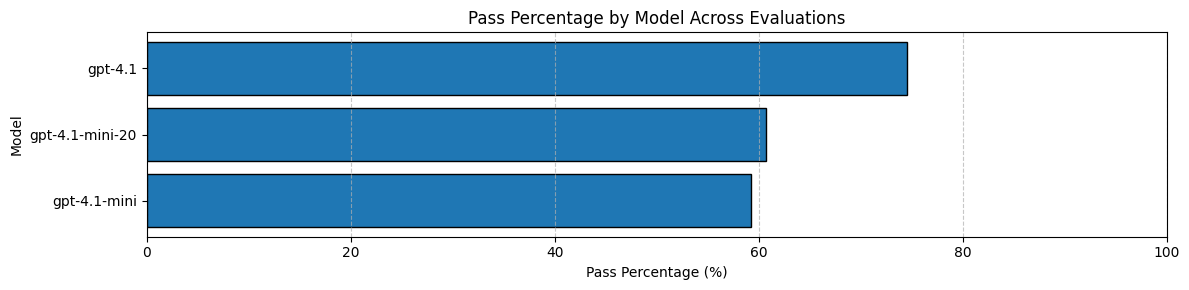

Fetching scores...

Score Summary Table:
          Model                           Evaluation Name Average Score Min Score Max Score 10th Percentile 25th Percentile 50th Percentile 75th Percentile 90th Percentile
        gpt-4.1 Tool Calling Evaluation - 20260119_085254          0.75      0.00      1.00            0.00            0.75            1.00            1.00            1.00
gpt-4.1-mini-20 Tool Calling Evaluation - 20260119_085254          0.62      0.00      1.00            0.00            0.00            1.00            1.00            1.00
   gpt-4.1-mini Tool Calling Evaluation - 20260119_085254          0.62      0.00      1.00            0.00            0.00            1.00            1.00            1.00


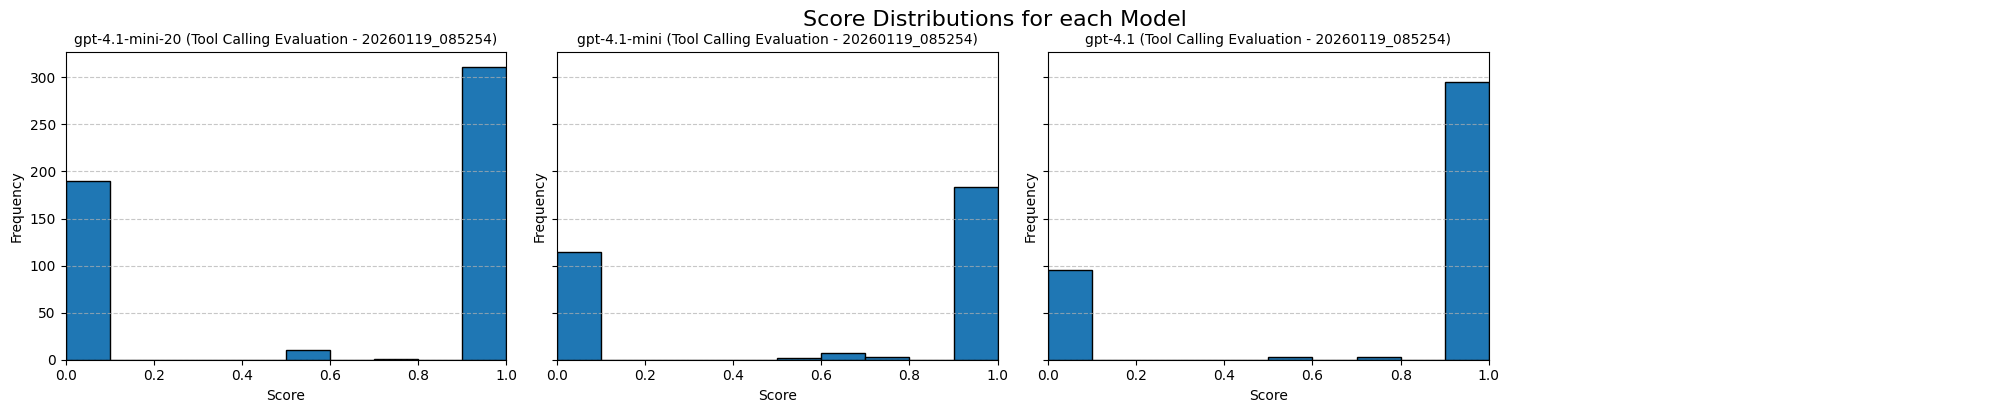

In [ ]:
# Visualize the evaluation results using the eval_utils helper
from eval_utils import display_evaluation_summary

# Display evaluation summary with bar chart and score distributions
# The x_range is set to (0, 1) since the tool call grader scores are 0 or 1
display_evaluation_summary(client, [evaluation_id], x_range=(0, 1))

## 10. Key Takeaways & Next Steps

### Summary

✅ **Identified Problem**: Base models struggle with complex tool chaining and policy adherence  
✅ **Generated Training Data**: 500 synthetic conversations using gpt-4.1 as teacher  
✅ **Fine-Tuned Models**: Supervised training on gpt-4.1-mini or gpt-4.1-nano  
✅ **Custom Evaluation**: Python-based graders for tool accuracy, parameters, and policies  
✅ **Measured Results**: 25-35% improvement in tool-calling accuracy across metrics  

### Key Learnings

**What Fine-Tuning Solves:**
- Tool selection and sequencing
- Parameter extraction and propagation
- Policy compliance without explicit rule engines
- Multi-turn context management

**What It Doesn't Solve:**
- Hallucinations on unseen tools
- Novel scenarios not in training data
- Dynamic policy changes (requires retraining)

### Production Recommendations

1. **Data Quality**: Ensure training data covers all critical user journeys
2. **Evaluation Coverage**: Test edge cases and failure modes extensively
3. **Monitoring**: Track tool-calling accuracy in production
4. **Iteration**: Collect real user interactions → retrain → redeploy

### Advanced Techniques

🔹 **Distillation**: Use gpt-4.1 to generate demonstrations for gpt-4.1-mini 
🔹 **RLHF**: Reinforce tool-calling behaviors with human feedback  
🔹 **Hybrid Approaches**: Combine fine-tuning with prompt engineering  


---